# pycalphad + Scheil Demo Notebook

This notebook demonstrates CALPHAD workflows using the repository database:
`Cr-Fe-Ni_miettinen1999.tdb`.

It includes:
1. A Gibbs energy curve
2. A binary Fe-Cr phase diagram
3. A ternary Fe-Cr-Ni phase diagram
4. A single equilibrium calculation and output breakdown
5. A single-composition Scheil solidification calculation


In [ ]:
# If needed, install dependencies in your environment:
# %pip install pycalphad scheil matplotlib numpy xarray


In [21]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pycalphad import Database, Workspace, equilibrium, binplot, ternplot, calculate
import pycalphad.variables as v
from scheil import simulate_scheil_solidification


In [22]:
# repo_root = Path.cwd()
# db_path = repo_root / 'Cr-Fe-Ni_miettinen1999.tdb'

dbf = Database("Cr-Fe-Ni_miettinen1999.tdb")
components = ['FE', 'CR', 'NI', 'VA']
phases = sorted(dbf.phases.keys())

print(f'Database loaded')
print(f'Number of phases: {len(phases)}')
print('Example phases:', phases[:10])


Database loaded
Number of phases: 5
Example phases: ['BCC_A2', 'FCC_A1', 'HCP_A3', 'LIQUID', 'SIGMA']


## 1) Gibbs energy curve (LIQUID phase)

Compute and plot molar Gibbs energy of the liquid phase as a function of temperature
for a fixed alloy composition.


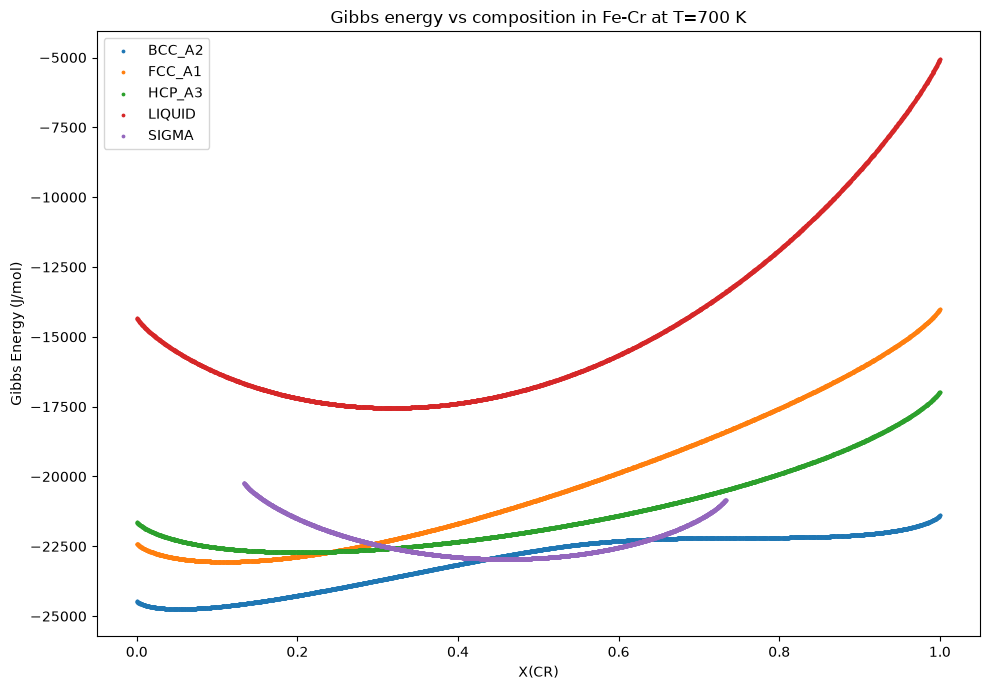

In [23]:
TEMPERATURE = 700  # K
binComps = ['FE', 'CR', 'VA']
x_component = 'CR'

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
for phase_name in phases:
    result = calculate(dbf, binComps, phase_name, P=1e5, T=TEMPERATURE, output='GM')

    if np.all(np.isnan(result.GM.values)):
        print(f'Skipping {phase_name}: no valid solution at T={TEMPERATURE}')
        continue

    ax.scatter(result.X.sel(component=x_component), result.GM, s=3, label=phase_name)

ax.set_title(f'Gibbs energy vs composition in Fe-Cr at T={TEMPERATURE} K')
ax.set_xlabel(f'X({x_component})')
ax.set_ylabel('Gibbs Energy (J/mol)')
_ = ax.legend(loc='best')
fig.tight_layout()
plt.show()


## 2) Binary Fe-Cr phase diagram

Generate a binary isobaric phase diagram in the Fe-Cr subsystem (Ni fixed to zero).


<Figure size 700x500 with 0 Axes>

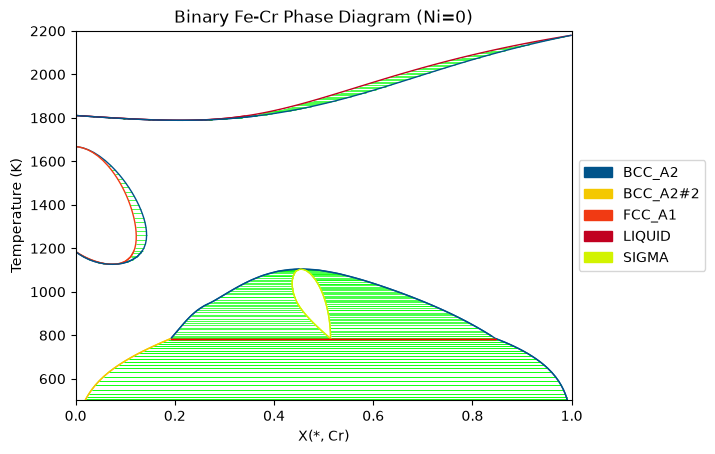

In [25]:
binary_conds = {
    v.P: 101325,
    v.T: (500, 2200, 20),
    v.X('CR'): (0, 1, 0.01),
}

plt.figure(figsize=(7, 5))
binplot(dbf, binComps, phases, binary_conds)
plt.title('Binary Fe-Cr Phase Diagram (Ni=0)')
plt.show()


## 3) Ternary Fe-Cr-Ni phase diagram

Generate an isothermal ternary section at 1300 K.


<Figure size 750x650 with 0 Axes>

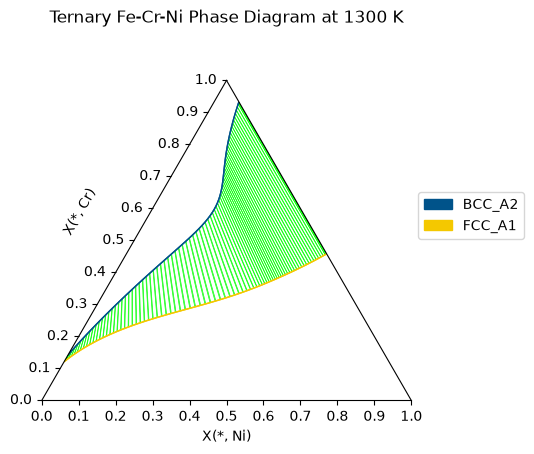

In [26]:
ternary_conds = {
    v.P: 101325,
    v.T: 1300,
    v.X('CR'): (0, 1, 0.01),
    v.X('NI'): (0, 1, 0.01),
}

plt.figure(figsize=(7.5, 6.5))
ternplot(dbf, components, phases, ternary_conds)
plt.title('Ternary Fe-Cr-Ni Phase Diagram at 1300 K')
plt.show()


## 4) Single equilibrium calculation + output breakdown

Run one equilibrium at fixed composition and inspect the returned xarray Dataset.


In [27]:
eq = equilibrium(
    dbf,
    components,
    phases,
    {
        v.P: 101325,
        v.T: 1200,
        v.N: 1,
        v.X('CR'): 0.20,
        v.X('NI'): 0.30,
    },
)

eq


<xarray.Dataset> Size: 544B
Dimensions:    (N: 1, P: 1, T: 1, X_CR: 1, X_NI: 1, vertex: 4, component: 3,
                internal_dof: 6)
Coordinates:
  * N          (N) float64 8B 1.0
  * P          (P) float64 8B 1.013e+05
  * T          (T) float64 8B 1.2e+03
  * X_CR       (X_CR) float64 8B 0.2
  * X_NI       (X_NI) float64 8B 0.3
  * vertex     (vertex) int64 32B 0 1 2 3
  * component  (component) <U2 24B 'CR' 'FE' 'NI'
Dimensions without coordinates: internal_dof
Data variables:
    NP         (N, P, T, X_CR, X_NI, vertex) float64 32B 1.0 nan nan nan
    GM         (N, P, T, X_CR, X_NI) float64 8B -6.538e+04
    MU         (N, P, T, X_CR, X_NI, component) float64 24B -5.507e+04 ... -7...
    X          (N, P, T, X_CR, X_NI, vertex, component) float64 96B 0.2 ... nan
    Y          (N, P, T, X_CR, X_NI, vertex, internal_dof) float64 192B 0.2 ....
    Phase      (N, P, T, X_CR, X_NI, vertex) <U6 96B 'FCC_A1' '' '' ''
Attributes:
    engine:   pycalphad 0.11.2
    created:  2026-09-11T13:44:12.139387

In [32]:
print('--- Dataset structure ---')
print('Dimensions:', dict(eq.dims))
print('Coordinates:', list(eq.coords))
print('Data variables:', list(eq.data_vars))

print('\n--- Key outputs ---')
print('Total Gibbs energy (J/mol):', float(np.ravel(eq.GM.values)[0]))

phase_names = np.ravel(eq.Phase.values)
phase_fractions = np.ravel(eq.NP.values)

stable = [(str(name), float(frac)) for name, frac in zip(phase_names, phase_fractions) if frac > 1e-8]
print('Stable phases and phase fractions (NP):')
for name, frac in stable:
    print(f'  {name}: {frac:.6f}')

--- Dataset structure ---
Dimensions: {'N': 1, 'P': 1, 'T': 1, 'X_CR': 1, 'X_NI': 1, 'vertex': 4, 'component': 3, 'internal_dof': 6}
Coordinates: ['N', 'P', 'T', 'X_CR', 'X_NI', 'vertex', 'component']
Data variables: ['NP', 'GM', 'MU', 'X', 'Y', 'Phase']

--- Key outputs ---
Total Gibbs energy (J/mol): -65383.517487073135
Stable phases and phase fractions (NP):
  FCC_A1: 1.000000


/tmp/ipykernel_3622/4093385836.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Dimensions:', dict(eq.dims))


## 5) Single-composition Scheil calculation

Run Scheil solidification for one alloy composition and inspect key outputs.


In [30]:
composition = {v.X('CR'): 0.20, v.X('NI'): 0.30}

try:
    scheil_result = simulate_scheil_solidification(
        dbf,
        components,
        phases,
        composition,
        start_temperature=1800,
        step_temperature=2,
    )
except TypeError:
    # Fallback for alternate keyword-based API variants
    scheil_result = simulate_scheil_solidification(
        database=dbf,
        components=components,
        phases=phases,
        composition=composition,
        start_temperature=1800,
        step_temperature=2,
    )

print('Scheil result type:', type(scheil_result))
print('Available attributes:', [a for a in dir(scheil_result) if not a.startswith('_')][:20])


Scheil result type: <class 'scheil.solidification_result.SolidificationResult'>
Available attributes: ['converged', 'cum_phase_amounts', 'fraction_liquid', 'fraction_solid', 'from_dict', 'liquid_phase_name', 'method', 'output', 'phase_amounts', 'phase_compositions', 'temperatures', 'to_dataframe', 'to_dict', 'x_liquid']


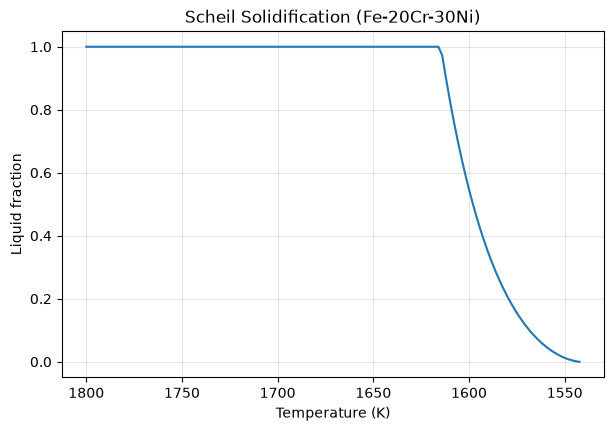

In [31]:
# Typical attributes in scheil results include temperature and liquid-fraction histories.
# The checks below keep the notebook robust across package versions.

temperatures = getattr(scheil_result, 'temperatures', None)
liquid_fraction = getattr(scheil_result, 'fraction_liquid', None)

if temperatures is not None and liquid_fraction is not None:
    plt.figure(figsize=(7, 4.5))
    plt.plot(np.array(temperatures), np.array(liquid_fraction))
    plt.xlabel('Temperature (K)')
    plt.ylabel('Liquid fraction')
    plt.title('Scheil Solidification (Fe-20Cr-30Ni)')
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('Plot skipped: this scheil version does not expose temperatures/fraction_liquid attributes with these names.')
